In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

os.chdir('..')
os.chdir(r'C:\Users\USER\Projects\Downscaling-of-satellite-based-air-quality-map')
print("Current folder:", os.getcwd())

Current folder: C:\Users\USER\Projects\Downscaling-of-satellite-based-air-quality-map


In [6]:
# Load your clean ML dataset
df = pd.read_csv('data/processed/ml_dataset.csv')

print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(df.head())

# Separate features (clues) and target (answer)
X = df[['elevation', 'population', 'landuse']]  # features
y = df['no2']                                    # target

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

Total rows: 15244
Columns: ['no2', 'elevation', 'population', 'landuse', 'road_density']
        no2  elevation  population   landuse  road_density
0  0.000000   0.218195    0.008241  0.715909           0.0
1  0.000957   0.217592    0.010818  0.715909           0.0
2  0.002872   0.217569    0.012778  0.715909           0.0
3  0.006267   0.217219    0.014113  0.715909           0.0
4  0.011143   0.216328    0.016637  0.715909           0.0

Features shape: (15244, 3)
Target shape: (15244,)


In [7]:
# Step 1: Split off 15% as test (locked away until the end)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42    # ensures same split every time you run
)

# Step 2: Split remaining into 70% train, 15% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.176,   # 0.176 × 0.85 ≈ 0.15 of total
    random_state=42
)

print(f"Training rows:   {len(X_train)} "
      f"({len(X_train)/len(df)*100:.0f}%)")
print(f"Validation rows: {len(X_val)} "
      f"({len(X_val)/len(df)*100:.0f}%)")
print(f"Test rows:       {len(X_test)} "
      f"({len(X_test)/len(df)*100:.0f}%)")

Training rows:   10676 (70%)
Validation rows: 2281 (15%)
Test rows:       2287 (15%)


In [8]:
# Train the simplest possible model first
baseline = LinearRegression()
baseline.fit(X_train, y_train)

# Predict on validation set
y_pred_baseline = baseline.predict(X_val)

# Calculate metrics (fixed for newer sklearn)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_baseline))
mae  = mean_absolute_error(y_val, y_pred_baseline)
r2   = r2_score(y_val, y_pred_baseline)
bias = np.mean(y_pred_baseline - y_val)

print("📊 Baseline Linear Regression Results:")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R²:   {r2:.4f}")
print(f"  Bias: {bias:.4f}")

📊 Baseline Linear Regression Results:
  RMSE: 0.1874
  MAE:  0.1487
  R²:   0.5075
  Bias: -0.0035


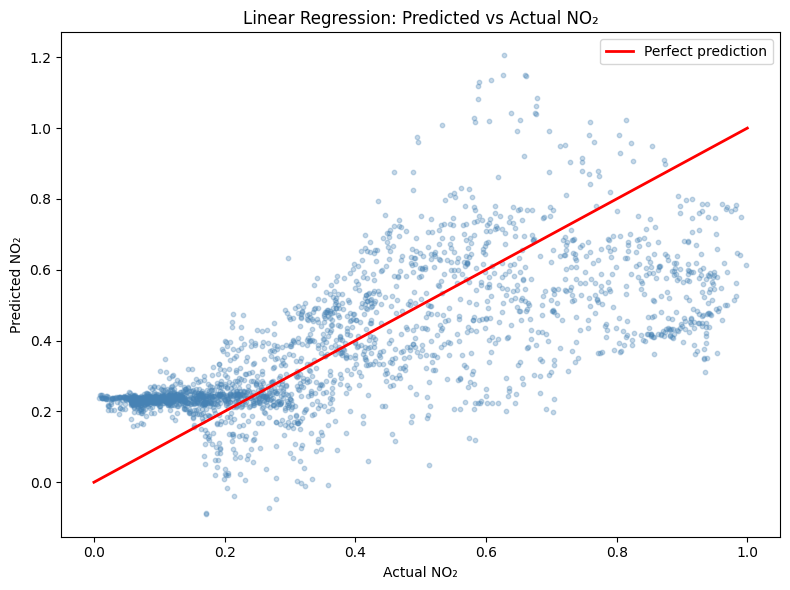

✅ Plot saved!


In [9]:
plt.figure(figsize=(8, 6))

# Scatter plot: predicted vs actual
plt.scatter(y_val, y_pred_baseline,
            alpha=0.3, s=10, color='steelblue')

# Perfect prediction line
plt.plot([0, 1], [0, 1],
         color='red', linewidth=2,
         label='Perfect prediction')

plt.xlabel('Actual NO₂')
plt.ylabel('Predicted NO₂')
plt.title('Linear Regression: Predicted vs Actual NO₂')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/baseline_predictions.png', dpi=300)
plt.show()

print("✅ Plot saved!")

In [10]:
# Train XGBoost
from xgboost import XGBRegressor

# Build XGBoost model
xgb_model = XGBRegressor(
    n_estimators=200,      # number of trees to build
    learning_rate=0.1,     # how fast it learns
    max_depth=6,           # how deep each tree can go
    random_state=42
)

# Train the model
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("✅ XGBoost model trained!")

✅ XGBoost model trained!


In [11]:
# Evaluate XGBoost 
# Predict on validation set
y_pred_xgb = xgb_model.predict(X_val)

# Calculate metrics
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_val, y_pred_xgb)
r2_xgb   = r2_score(y_val, y_pred_xgb)
bias_xgb = np.mean(y_pred_xgb - y_val)

print("📊 XGBoost Results:")
print(f"  RMSE: {rmse_xgb:.4f}")
print(f"  MAE:  {mae_xgb:.4f}")
print(f"  R²:   {r2_xgb:.4f}")
print(f"  Bias: {bias_xgb:.4f}")

# Compare with baseline
print("\n📈 Improvement over baseline:")
print(f"  RMSE: {rmse:.4f} → {rmse_xgb:.4f} "
      f"({'✅ better' if rmse_xgb < rmse else '❌ worse'})")
print(f"  R²:   {r2:.4f} → {r2_xgb:.4f} "
      f"({'✅ better' if r2_xgb > r2 else '❌ worse'})")

📊 XGBoost Results:
  RMSE: 0.0833
  MAE:  0.0550
  R²:   0.9028
  Bias: -0.0034

📈 Improvement over baseline:
  RMSE: 0.1874 → 0.0833 (✅ better)
  R²:   0.5075 → 0.9028 (✅ better)


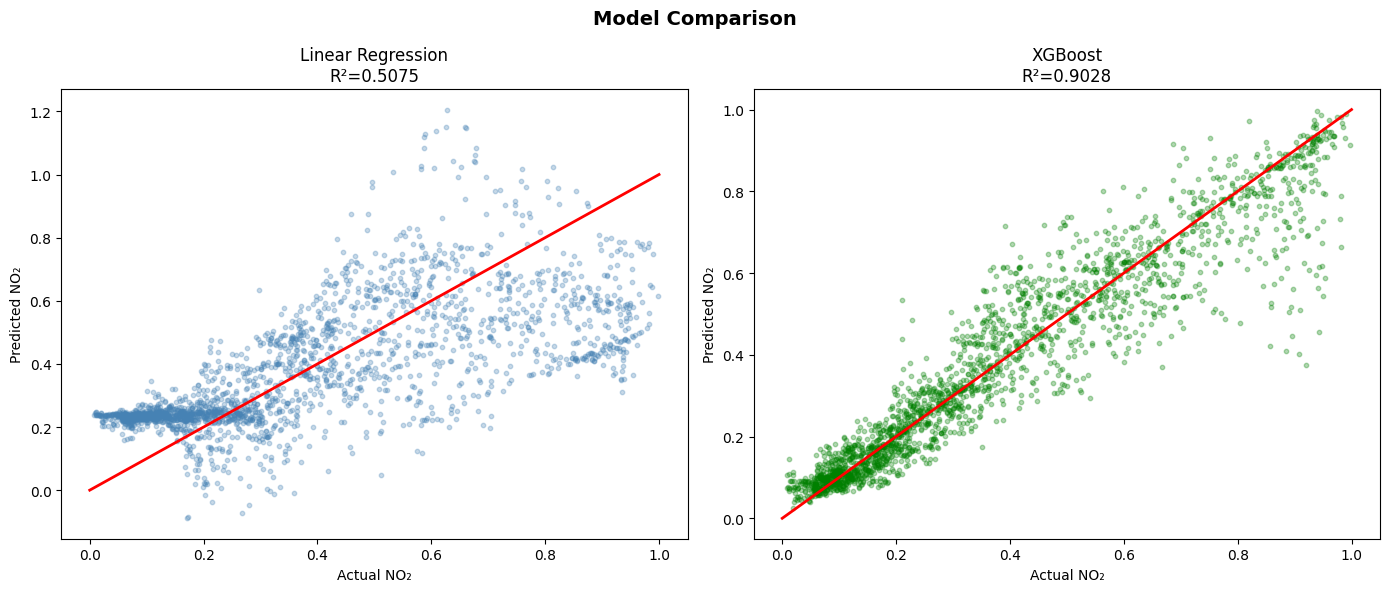

In [12]:
# Compare Both Models Visually
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Baseline plot
axes[0].scatter(y_val, y_pred_baseline,
                alpha=0.3, s=10, color='steelblue')
axes[0].plot([0,1],[0,1], color='red', linewidth=2)
axes[0].set_title(f'Linear Regression\nR²={r2:.4f}')
axes[0].set_xlabel('Actual NO₂')
axes[0].set_ylabel('Predicted NO₂')

# XGBoost plot
axes[1].scatter(y_val, y_pred_xgb,
                alpha=0.3, s=10, color='green')
axes[1].plot([0,1],[0,1], color='red', linewidth=2)
axes[1].set_title(f'XGBoost\nR²={r2_xgb:.4f}')
axes[1].set_xlabel('Actual NO₂')
axes[1].set_ylabel('Predicted NO₂')

plt.suptitle('Model Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=300)
plt.show()

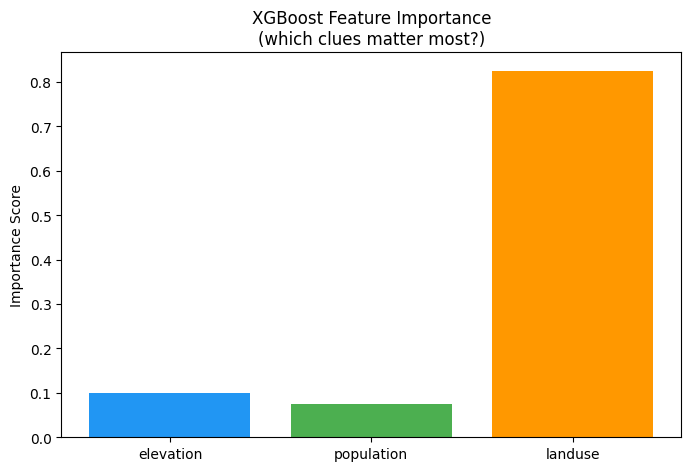

  elevation: 0.0996
  population: 0.0746
  landuse: 0.8259


In [13]:
# Feature Importance
# Which feature does XGBoost think is most important?
importance = xgb_model.feature_importances_
features = ['elevation', 'population', 'landuse']

plt.figure(figsize=(8, 5))
plt.bar(features, importance, color=['#2196F3','#4CAF50','#FF9800'])
plt.title('XGBoost Feature Importance\n(which clues matter most?)')
plt.ylabel('Importance Score')
plt.savefig('outputs/feature_importance.png', dpi=300)
plt.show()

for f, i in zip(features, importance):
    print(f"  {f}: {i:.4f}")

In [14]:
# Reload Data and Resplit
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Reload updated dataset with road density
df = pd.read_csv('data/processed/ml_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Features now include road_density!
X = df[['elevation', 'population', 
        'landuse', 'road_density']]
y = df['no2']

# Same split as before
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, 
    test_size=0.176, random_state=42
)

print(f"\nTraining rows:   {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"Test rows:       {len(X_test)}")
print(f"\n✅ Data reloaded with road density feature!")

Dataset shape: (15244, 5)
Columns: ['no2', 'elevation', 'population', 'landuse', 'road_density']

Training rows:   10676
Validation rows: 2281
Test rows:       2287

✅ Data reloaded with road density feature!


In [15]:
# Retrain XGBoost With New Feature
from xgboost import XGBRegressor
from sklearn.metrics import (mean_squared_error, 
                             r2_score, 
                             mean_absolute_error)

# Train XGBoost with road density included
xgb_v2 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_v2.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Evaluate
y_pred_v2 = xgb_v2.predict(X_val)

rmse_v2 = np.sqrt(mean_squared_error(y_val, y_pred_v2))
mae_v2  = mean_absolute_error(y_val, y_pred_v2)
r2_v2   = r2_score(y_val, y_pred_v2)
bias_v2 = np.mean(y_pred_v2 - y_val)

print("📊 XGBoost v2 (with road density):")
print(f"  RMSE: {rmse_v2:.4f}")
print(f"  MAE:  {mae_v2:.4f}")
print(f"  R²:   {r2_v2:.4f}")
print(f"  Bias: {bias_v2:.4f}")

# Compare with previous XGBoost
print("\n📈 Improvement over XGBoost v1:")
print(f"  RMSE: {rmse_xgb:.4f} → {rmse_v2:.4f} "
      f"({'✅ better' if rmse_v2 < rmse_xgb else '❌ worse'})")
print(f"  R²:   {r2_xgb:.4f} → {r2_v2:.4f} "
      f"({'✅ better' if r2_v2 > r2_xgb else '❌ worse'})")

📊 XGBoost v2 (with road density):
  RMSE: 0.0757
  MAE:  0.0503
  R²:   0.9196
  Bias: -0.0024

📈 Improvement over XGBoost v1:
  RMSE: 0.0833 → 0.0757 (✅ better)
  R²:   0.9028 → 0.9196 (✅ better)


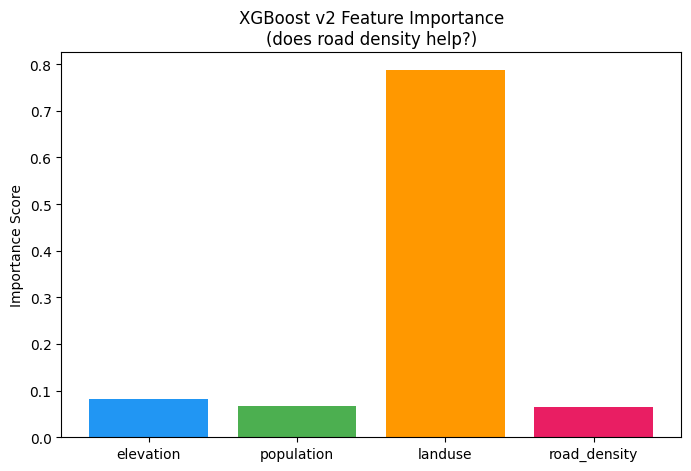

  elevation: 0.0821
  population: 0.0671
  landuse: 0.7866
  road_density: 0.0642


In [16]:
#  Updated Feature Importance
import matplotlib.pyplot as plt

features_v2 = ['elevation', 'population', 
               'landuse', 'road_density']
importance_v2 = xgb_v2.feature_importances_

plt.figure(figsize=(8, 5))
plt.bar(features_v2, importance_v2, 
        color=['#2196F3','#4CAF50','#FF9800','#E91E63'])
plt.title('XGBoost v2 Feature Importance\n'
          '(does road density help?)')
plt.ylabel('Importance Score')
plt.savefig('outputs/feature_importance_v2.png', dpi=300)
plt.show()

for f, i in zip(features_v2, importance_v2):
    print(f"  {f}: {i:.4f}")

In [17]:
# Full Model Comparison
# Complete scorecard of all models
print("=" * 45)
print("📊 COMPLETE MODEL COMPARISON")
print("=" * 45)
print(f"{'Model':<25} {'R²':>6}  {'RMSE':>6}")
print("-" * 45)
print(f"{'Linear Regression':<25} "
      f"{r2:>6.4f}  {rmse:>6.4f}")
print(f"{'XGBoost v1':<25} "
      f"{r2_xgb:>6.4f}  {rmse_xgb:>6.4f}")
print(f"{'XGBoost v2 + roads':<25} "
      f"{r2_v2:>6.4f}  {rmse_v2:>6.4f}")
print("=" * 45)

if r2_v2 > r2_xgb:
    improvement = (r2_v2 - r2_xgb) * 100
    print(f"\n✅ Road density improved R² by "
          f"{improvement:.2f} percentage points!")
else:
    print(f"\n🤔 Road density didn't improve the model.")
    print("This is also a valid scientific finding!")

📊 COMPLETE MODEL COMPARISON
Model                         R²    RMSE
---------------------------------------------
Linear Regression         0.5075  0.1874
XGBoost v1                0.9028  0.0833
XGBoost v2 + roads        0.9196  0.0757

✅ Road density improved R² by 1.68 percentage points!
